<a href="https://colab.research.google.com/github/VictorCabrejos/ai_med_scanner/blob/master/CNN_para_Diagnostico_de_Neumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [0]:
###import packages for project

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import copy
import time
import PIL
import scipy.ndimage as nd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
# !pip install -U -q kaggle
# !mkdir -p ~/.kaggle

In [0]:
# !mkdir .kaggle
# !ls -a 

.  ..  .config	drive  sample_data


In [7]:
!pip install -U -q kaggle
!mkdir -p ~/.kaggle

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"thevictor23","key":"c98e5f7f4eb90fed09eef8e9731d5b76"}'}

In [8]:
!cp kaggle.json ~/.kaggle/
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

 99% 2.28G/2.29G [00:50<00:00, 68.1MB/s]
100% 2.29G/2.29G [00:50<00:00, 48.6MB/s]


In [0]:
# import os
# os.environ['KAGGLE_USERNAME'] = "thevictor23" # username from the json file
# os.environ['KAGGLE_KEY'] = "c98e5f7f4eb90fed09eef8e9731d5b76" # key from the json file
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia # api copied from kaggle

100% 2.29G/2.29G [00:38<00:00, 16.4MB/s]
100% 2.29G/2.29G [00:39<00:00, 63.1MB/s]


In [0]:
# import json
# token = {"username":"thevictor23","key":"c98e5f7f4eb90fed09eef8e9731d5b76"}
# with open('/content/.kaggle/kaggle.json', 'w') as file:
#     json.dump(token, file)

In [0]:
# !chmod 600 /content/.kaggle/kaggle.json

In [9]:
!apt install pv
!unzip -o /content/chest-xray-pneumonia.zip
# os.remove('chest-xray-pneumonia.zip')
# !unzip -o /content/chest_xray.zip  | pv -l >/dev/null
# os.remove('chest_xray.zip')

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following packages were automatically installed and are no longer required:
  cuda-cufft-10-1 cuda-cufft-dev-10-1 cuda-curand-10-1 cuda-curand-dev-10-1
  cuda-cusolver-10-1 cuda-cusolver-dev-10-1 cuda-cusparse-10-1
  cuda-cusparse-dev-10-1 cuda-license-10-2 cuda-npp-10-1 cuda-npp-dev-10-1
  cuda-nsight-10-1 cuda-nsight-compute-10-1 cuda-nsight-systems-10-1
  cuda-nvgraph-10-1 cuda-nvgraph-dev-10-1 cuda-nvjpeg-10-1
  cuda-nvjpeg-dev-10-1 cuda-nvrtc-10-1 cuda-nvrtc-dev-10-1 cuda-nvvp-10-1
  libcublas10 libnvidia-common-430 nsight-compute-2019.5.0
  nsight-systems-2019.5.2
Use 'apt autoremove' to remove them.
Suggested packages:
  doc-base
The following NEW packages will be installed:
  pv
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 48.3 kB of archives.
After this operation, 123 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu b

In [0]:
## data augmentation with torchvision.transforms

transformers = {'train_transforms' : transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
]),
'test_transforms' : transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
]),
'valid_transforms' : transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])}

In [0]:
trans = ['train_transforms','valid_transforms','test_transforms']

In [0]:
# chest-xray-pneumonia.zip to /content
path = "/content/chest_xray/"
categories = ['train','val','test']
dset = {x : torchvision.datasets.ImageFolder(path+x, transform=transformers[y]) for x,y in zip(categories, trans)}

In [0]:
# Using the torchvision.datasets.ImageFolder module we load images from our dataset directory
dataset_sizes = {x : len(dset[x]) for x in ["train","test","val"]}

In [14]:
dataset_sizes['train']

5216

In [0]:
num_threads = 0
dataloaders =  {x : torch.utils.data.DataLoader(dset[x], batch_size=16, shuffle=True, num_workers=num_threads)
               for x in categories}

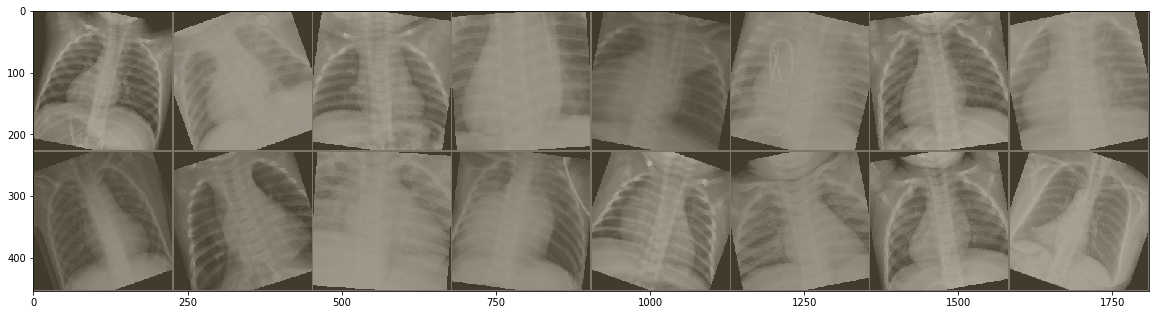

In [26]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1,2,0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std*inp + mean
    inp = np.clip(inp,0,1)
    plt.imshow(inp)


    if title is not None:
        plt.title(title)
    plt.pause(0.001)
    
inputs, classes = next(iter(dataloaders["train"]))
out = torchvision.utils.make_grid(inputs)
# class_names = dataset["train"].classes

plt.figure(figsize=(20,10))
imshow(out)


In [0]:
# Pytorch Neural Network module: https://pytorch.org/docs/stable/_modules/torch/nn/modules/module.html
# Defining the model class
# Inheriting from the nn.Module


##Build model
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()

        # Transfer Learning
        # leveraging the feature extractor of ResNet-152 
        #  #obtain the ResNet model from torchvision.model library
        self.model = torchvision.models.resnet152(pretrained=True)

        # Building classifier and since we are classifying the images
        # into NORMAL and PNEMONIA, we output a two-dimensional tensor.
        self.classifier = nn.Sequential(
            nn.Linear(self.model.fc.in_features,2),
            nn.LogSoftmax(dim=1)
        )

        # Pytorch provides us with the ability to take and freeze 
        # these powerful feature extractors, attach our own classifiers 
        # depending on our problem domain and train the resulting model to suit our problem
        # Requires_grad = False 
        # denies the ResNet model the ability 
        # to update its parameters hence make it unable to train.
        for params in self.model.parameters():
            params.requires_grad = False
        self.model.fc = self.classifier

    # Every model built from the nn.Module requires 
    # that we override the  forward function    
    def forward(self, x):
        return self.model(x)
    

    # Pytorch Blitz: https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html
    
    def fit(self, dataloaders, num_epochs):
        train_on_gpu = torch.cuda.is_available()
        optimizer = optim.Adam(self.model.fc.parameters())
        scheduler = optim.lr_scheduler.StepLR(optimizer, 4)
        criterion = nn.NLLLoss()
        since = time.time()
        
        best_model_wts = copy.deepcopy(self.model.state_dict())
        best_acc =0.0
        if train_on_gpu:
            self.model = self.model.cuda()
        for epoch in range(1, num_epochs+1):
            print("epoch {}/{}".format(epoch, num_epochs))
            print("-" * 10)
            
            for phase in ['train','test']:
                if phase == 'train':
                    scheduler.step()
                    self.model.train()
                else:
                    self.model.eval()
                
                running_loss = 0.0
                running_corrects = 0.0
                
                for inputs, labels in dataloaders[phase]:
                    if train_on_gpu:
                        inputs = inputs.cuda()
                        labels = labels.cuda()
                    optimizer.zero_grad()
                    
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = self.model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)
                        
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                    
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]
                print("{} loss:  {:.4f}  acc: {:.4f}".format(phase, epoch_loss, epoch_acc))
                
                if phase == 'test' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(self.model.state_dict())
        
        time_elapsed = time.time() - since
        print('time completed: {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 600))
        print("best val acc: {:.4f}".format(best_acc))
        
        self.model.load_state_dict(best_model_wts)
        return self.model

In [17]:
model = Model()

Downloading: "https://download.pytorch.org/models/resnet152-b121ed2d.pth" to /root/.cache/torch/checkpoints/resnet152-b121ed2d.pth
100%|██████████| 230M/230M [00:06<00:00, 37.7MB/s]


In [19]:
model_ft = model.fit(dataloaders,3)

epoch 1/3
----------


/usr/local/lib/python3.6/dist-packages/torch/optim/lr_scheduler.py:100: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule.See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  "https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate", UserWarning)


train loss:  0.1910  acc: 0.9268
test loss:  0.3884  acc: 0.8333
epoch 2/3
----------
train loss:  0.1836  acc: 0.9254
test loss:  0.4143  acc: 0.8333
epoch 3/3
----------
train loss:  0.2035  acc: 0.9181
test loss:  0.5494  acc: 0.8077
time completed: 7m 422s
best val acc: 0.8333


In [0]:
# state_dict = torch.load("c:/users/vmc62/desktop/resnet152-b121ed2d.pth")
# model.model.load_state_dict(state_dict)
model_ft = model.model

# torch.save(model.state_dict(), PATH)

In [0]:
# loader = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),
#                             transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])
# def image_loader(image_name):
#     image = PIL.Image.open(image_name).convert("RGB")
#     image = loader(image).float()
#     image = image.unsqueeze(0)
#     return image

In [0]:
# image_path = 'c:/users/henry/datasets/chest_xray/chest_xray/test/PNEUMONIA/person1949_bacteria_4880.jpeg'
# image_path = '/content/chest_xray/train/PNEUMONIA/person1945_bacteria_4872.jpeg'
# img = image_loader(image_path)

In [0]:
class LayerActivations():
    features=[]
    def __init__(self,model):
        self.hooks = []
        self.hooks.append(model.layer4.register_forward_hook(self.hook_fn))
    def hook_fn(self,module,input,output):
        self.features.append(output)
    def remove(self):
        for hook in self.hooks:
            hook.remove()

In [0]:
acts = LayerActivations(model_ft)

In [0]:
loader = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])

def image_loader(image_name):
    image = PIL.Image.open(image_name).convert("RGB")
    image = loader(image).float()
    image = image.unsqueeze(0) 
    return image

image_path = '/content/chest_xray/test/PNEUMONIA/person100_bacteria_477.jpeg'

#load image and perform a forward pass through our model.
img = image_loader(image_path)

logps =  model_ft(img.cuda() if torch.cuda.is_available() else img)

''' version 1.0 
# out_features = acts.features[0]
# out_features = torch.squeeze(out_features, dim=0)
# out_features = np.transpose(out_features,axes=(1,2,0))
'''


#since we have performed a forward pass through our model, we can obtain activations 
# from layer(model.layer4) defined in the LayerActivation class from the features 
# list and take out the batch dimension.
out_features = acts.features[0].squeeze(0) 

# Changes shape from 2048 x 7 x7 to 7 x 7 x 2048. Just performs 
# a matrix transpose on the output features tensor.
out_features = np.transpose(out_features.cpu(),(1,2,0)) 

In [0]:


# Our final model layer is a log-softmax activation. 
# We perform torch.exp to take out the log and obtain the softmax values.
ps = torch.exp(logps) 

# Obtain the axis of the predicted class.
pred = np.argmax(ps.cpu().detach())

''' Version 1.0
# W = model_ft.fc[0].weight
# top_probs, top_classes = torch.topk(ps, k=2)
# pred = np.argmax(ps.detach())
# w = W[pred,:]
'''

#We obtain all the weights connecting the Global Average Pooling layer 
# to the final fully connected layer.
W = model_ft.fc[0].weight 

# We obtain the weights associated with the predicted class 
# which is a 2048 dimensional vector.
w = W[pred,:] 

In [0]:
cam = np.dot(out_features.cpu().detach(),  w.detach().cpu())
#dot product between a 7x7x2048 tensor and a 2048 tensor yields a 7x7 tensor.
#cam will therefore have a shape of 7x7.

In [0]:
class_activation = nd.zoom(cam, zoom=(32,32),order=1)

In [0]:
img = torch.squeeze(img,0)
img = np.transpose(img,(1,2,0))
mean = np.array([0.5,0.5,0.5])
std =  np.array([0.5,0.5,0.5])
img = img.numpy()
img = (img + mean) * std
img = np.clip(img, a_max=1, a_min=0)

Text(0.5, 1.0, 'PNEUMONIA')

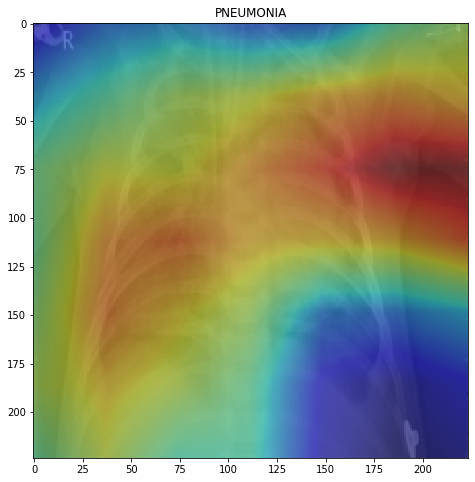

In [81]:
plt.figure(figsize=(16,8))
plt.imshow(class_activation, cmap='jet',alpha=1)
plt.imshow(img, alpha=0.55)
plt.title(dset['test'].classes[pred])